<a href="https://colab.research.google.com/github/jennyt14/math-228-phys-insprd-machine-learning/blob/main/inv_logistic_pinn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inverse Problem with Logistic Growth Physics-Informed Neural Network Example**

---

Material came from UC Irvine Math 228 Course (Spring 2026).

**Problem Setup:** We want to learn the logistic growth equation:
$$\frac{dx(t)}{dt} = λ x(t) (1-(x(t) / \theta)^α)$$ with initial condition: $$x(0) = p_0.$$ The parameters $λ, θ, p_0$, and $α$ are unknown. The goal is to find those parameters that fit our given data.


In [2]:
#import libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

np.random.seed(0)
torch.manual_seed(0)

## Generate Data

In [3]:
# True parameters
lambda_true = 0.8 # growth rate
theta_true = 3.0 # carrying capacity
alpha_true = 1.2     # Shape parameter
p0_true = 0.5        # Initial condition

# Ground truth logistic growth solution
def ground_truth(t):
    return theta_true * (1.0 + (((theta_true / p0_true) ** alpha_true) - 1.0) * torch.exp(-alpha_true * lambda_true * t)) ** (-1.0 / alpha_true)

print(f"True parameters: λ={lambda_true}, θ={theta_true}, α={alpha_true}, p0={p0_true}")

True parameters: λ=0.8, θ=3.0, α=1.2, p0=0.5


In [4]:
# Generate noisy training data
n_points = 8
noise_std = 0.01
g_noise = torch.randn(n_points, 1) * noise_std

# Generate time points
X = torch.linspace(0, 5, n_points).view(-1, 1)

# Generate population values with noise
Y = ground_truth(X) + g_noise

print(f"Generated {n_points} data points with noise std = {noise_std}")
print(f"Time range: {X.min().item():.1f} to {X.max().item():.1f}")

Generated 8 data points with noise std = 0.01
Time range: 0.0 to 5.0


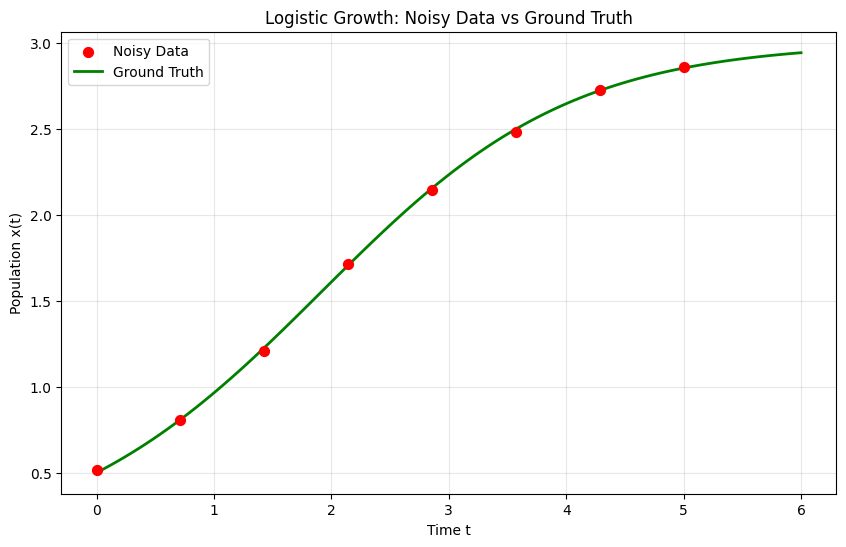

In [5]:
# Plot the noisy data and ground truth
t_plot = torch.linspace(0, 6, 100).view(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X.numpy(), Y.numpy(), color='red', s=50, label='Noisy Data', zorder=5)
plt.plot(t_plot.numpy(), ground_truth(t_plot).numpy(), color='green', linewidth=2, label='Ground Truth')
plt.xlabel('Time t')
plt.ylabel('Population x(t)')
plt.title('Logistic Growth: Noisy Data vs Ground Truth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Define Neural Network with Learnable Parameters

**Physics-Informed PDE Solution Representation:**
We represent the PDE solution using: $$x(t, p_0, W) = p_0 + NN(t, W) \cdot t,$$ where $p_0$ is a trainable parameter respresenting the initial condition, $NN(t, W)$ is a standard feedforward neural network, and $W$ represents all the weights and biases.

In [6]:
class InverseLogisticNet(nn.Module):
    def __init__(self, depth, width, train_lambda=True, train_theta=True, train_alpha=True, train_p0=True):
        super(InverseLogisticNet, self).__init__()

        # Neural network layers for x(t, W)
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(1, width))

        for i in range(depth - 2):
            self.layers.append(nn.Linear(width, width))

        self.layers.append(nn.Linear(width, 1))

        # Store which parameters are trainable
        self.train_lambda = train_lambda
        self.train_theta = train_theta
        self.train_alpha = train_alpha
        self.train_p0 = train_p0

        # Initialize parameters based on trainability
        if train_lambda:
            # Random perturbation around true value by up to ±20%
            pct_change = (torch.rand(1) - 0.5) * 0.2
            init_lambda = lambda_true * (1 + pct_change)
            self.lambda_param = nn.Parameter(init_lambda)
        else:
            # Fixed to ground truth (not trainable)
            self.lambda_param = nn.Parameter(torch.tensor([lambda_true]), requires_grad=False)

        if train_theta:
            pct_change = (torch.rand(1) - 0.5) * 0.2
            init_theta = theta_true * (1 + pct_change)
            self.theta_param = nn.Parameter(init_theta)
        else:
            self.theta_param = nn.Parameter(torch.tensor([theta_true]), requires_grad=False)

        if train_alpha:
            pct_change = (torch.rand(1) - 0.5) * 0.2
            init_alpha = alpha_true * (1 + pct_change)
            self.alpha_param = nn.Parameter(init_alpha)
        else:
            self.alpha_param = nn.Parameter(torch.tensor([alpha_true]), requires_grad=False)

        if train_p0:
            pct_change = (torch.rand(1) - 0.5) * 0.2
            init_p0 = p0_true * (1 + pct_change)
            self.p0_param = nn.Parameter(init_p0)
        else:
            self.p0_param = nn.Parameter(torch.tensor([p0_true]), requires_grad=False)

    def forward(self, t):
        """
        Compute the population at time t

        Mathematical Representation: x(t, p_0, W) = p0 + NN(t,W) * t

        When t=0, x(0) = p0 + NN(0,W)*0 = p0
           This automatically satisfies the initial condition x(0) = p0.
           p0 has a clear physical meaning as the
           initial population, making it directly interpretable and trainable
        """
        # Pass time through neural network layers
        nn_output = t
        for layer in self.layers[:-1]:
            nn_output = torch.tanh(layer(nn_output))
        nn_output = self.layers[-1](nn_output)

        return self.p0_param + nn_output * t

    def get_parameters(self):
        """Return current values of learnable parameters"""
        return {
            'lambda': self.lambda_param.item(),
            'theta': self.theta_param.item(),
            'alpha': self.alpha_param.item(),
            'p0': self.p0_param.item()
        }

    def get_trainable_status(self):
        """Return which parameters are trainable"""
        return {
            'lambda': self.train_lambda,
            'theta': self.train_theta,
            'alpha': self.train_alpha,
            'p0': self.train_p0
        }

    def physics_residual(self, t):
        """Compute the physics residual for the logistic growth ODE"""
        t.requires_grad_(True)
        x = self.forward(t)

        # Compute dx/dt using automatic differentiation
        dx_dt = torch.autograd.grad(
            outputs=x, inputs=t,
            grad_outputs=torch.ones_like(x),
            create_graph=True
        )[0]

        # Logistic growth equation: dx/dt = λ*x*(1-(x/θ)^α)
        logistic_term = self.lambda_param * x * (1.0 - (x / (self.theta_param)) ** (self.alpha_param))

        # Physics residual: should be zero when ODE is satisfied
        residual = dx_dt - logistic_term

        return residual

# Configuration: Set which parameters to train
train_lambda = True
train_theta = True
train_alpha = False
train_p0 = True

# Initialize model
depth, width = 3, 32
model = InverseLogisticNet(depth, width, train_lambda, train_theta, train_alpha, train_p0)

# Print initial parameters and trainable status
params_init = model.get_parameters()
trainable_status = model.get_trainable_status()

print("Parameter Configuration:")
print("-" * 40)
for name, value in params_init.items():
    status = "TRAINABLE" if trainable_status[name] else "FIXED"
    true_val = {'lambda': lambda_true, 'theta': theta_true, 'alpha': alpha_true, 'p0': p0_true}[name]
    print(f"  {name}: {value:.4f} (True: {true_val:.4f}) [{status}]")

Parameter Configuration:
----------------------------------------
  lambda: 0.7543 (True: 0.8000) [TRAINABLE]
  theta: 2.9004 (True: 3.0000) [TRAINABLE]
  alpha: 1.2000 (True: 1.2000) [FIXED]
  p0: 0.5394 (True: 0.5000) [TRAINABLE]


## Traning Function with Parameter Logging
The training processs optimizes two main loss components:


1.   **Data Loss:** Ensures network fits observed data $$L_{data} = \frac{1}{N} \sum^N_{i=1} (x(t_i, W) - y_i)^2.$$
2.   **Physics Loss:** Enforces logistic growth ODE $$L_{physics} = \frac{1}{M} \sum^M_{j=1} \left(\frac{dx}{dt} - λx (1-(x/\theta)^\alpha) \right)^2.$$
3. **Total Loss:** $$L_{total} = L_{data} + λ_{phys} \cdot L_{physics}$$

Note: The initial condition loss was removed for easier convergence.

In [7]:
def train_inverse_logistic(model, epochs, lambda_physics=1.0, learning_rate=0.001):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Loss tracking
    data_losses = []
    physics_losses = []
    total_losses = []

    # Parameter evolution tracking
    lambda_history = []
    theta_history = []
    alpha_history = []
    p0_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # 1. Data Loss: fit to observed data points
        x_pred = model(X)
        data_loss = torch.mean((x_pred - Y)**2)

        # 2. Physics Loss: satisfy logistic growth ODE (using global t_physics)
        physics_residual = model.physics_residual(t_physics)
        physics_loss = torch.mean(physics_residual**2)

        # 3. Total Loss (simplified - no IC loss)
        total_loss = data_loss + lambda_physics * physics_loss

        # Backpropagation
        total_loss.backward()
        optimizer.step()

        # Store losses
        data_losses.append(data_loss.item())
        physics_losses.append(physics_loss.item())
        total_losses.append(total_loss.item())

        # Store parameter evolution
        params = model.get_parameters()
        lambda_history.append(params['lambda'])
        theta_history.append(params['theta'])
        alpha_history.append(params['alpha'])
        p0_history.append(params['p0'])

        # Print progress
        if epoch % 200 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:4d}: Total={total_loss.item():.6f}, "
                  f"Data={data_loss.item():.6f}, Physics={physics_loss.item():.6f}")
            print(f"           Params: λ={params['lambda']:.4f}, θ={params['theta']:.4f}, "
                  f"α={params['alpha']:.4f}, p0={params['p0']:.4f}")

    return {
        'data_losses': data_losses,
        'physics_losses': physics_losses,
        'total_losses': total_losses,
        'lambda_history': lambda_history,
        'theta_history': theta_history,
        'alpha_history': alpha_history,
        'p0_history': p0_history
    }

print("Training function defined. Ready to start training...")

Training function defined. Ready to start training...


In [8]:
# Define physics training points outside the training function
t_phy_end = 5.0  # End time for physics training
t_physics = torch.linspace(0, t_phy_end, 100).view(-1, 1)

print(f"Physics training region: [0, {t_phy_end}] with {len(t_physics)} points")

Physics training region: [0, 5.0] with 100 points


In [9]:
# Training configuration
epochs = 10000
lambda_physics = 1.0  # Weight for physics constraint
learning_rate = 0.0001

print(f"Training for {epochs} epochs")
print(f"Physics weight: {lambda_physics}, Learning rate: {learning_rate}")
print(f"Target parameters: λ={lambda_true}, θ={theta_true}, α={alpha_true}, p0={p0_true}")
print("-" * 80)

# Train the model
results = train_inverse_logistic(model, epochs, lambda_physics, learning_rate)

# Final results
params_final = model.get_parameters()
trainable_status = model.get_trainable_status()

print("\n" + "="*80)
print("FINAL RESULTS:")
print(f"Learned parameters: λ={params_final['lambda']:.4f}, θ={params_final['theta']:.4f}, "
      f"α={params_final['alpha']:.4f}, p0={params_final['p0']:.4f}")
print(f"True parameters:    λ={lambda_true:.4f}, θ={theta_true:.4f}, "
      f"α={alpha_true:.4f}, p0={p0_true:.4f}")
print("\nParameter errors (only for trainable parameters):")
for param_name, is_trainable in trainable_status.items():
    if is_trainable:
        true_val = {'lambda': lambda_true, 'theta': theta_true, 'alpha': alpha_true, 'p0': p0_true}[param_name]
        learned_val = params_final[param_name]
        error = abs(learned_val - true_val)
        print(f"  Δ{param_name} = {error:.4f}")
    else:
        print(f"  {param_name} = FIXED (not trained)")

Training for 10000 epochs
Physics weight: 1.0, Learning rate: 0.0001
Target parameters: λ=0.8, θ=3.0, α=1.2, p0=0.5
--------------------------------------------------------------------------------
Epoch    0: Total=2.019382, Data=1.935957, Physics=0.083425
           Params: λ=0.7542, θ=2.9003, α=1.2000, p0=0.5395
Epoch  200: Total=0.132387, Data=0.077425, Physics=0.054962
           Params: λ=0.7477, θ=2.9162, α=1.2000, p0=0.5486
Epoch  400: Total=0.052502, Data=0.025056, Physics=0.027446
           Params: λ=0.7410, θ=2.9329, α=1.2000, p0=0.5538
Epoch  600: Total=0.022057, Data=0.008313, Physics=0.013744
           Params: λ=0.7346, θ=2.9443, α=1.2000, p0=0.5564
Epoch  800: Total=0.013589, Data=0.005234, Physics=0.008356
           Params: λ=0.7325, θ=2.9519, α=1.2000, p0=0.5565
Epoch 1000: Total=0.009936, Data=0.003997, Physics=0.005939
           Params: λ=0.7346, θ=2.9580, α=1.2000, p0=0.5554
Epoch 1200: Total=0.007407, Data=0.002928, Physics=0.004479
           Params: λ=0.7394, 

## Visualization: Loss Evolution

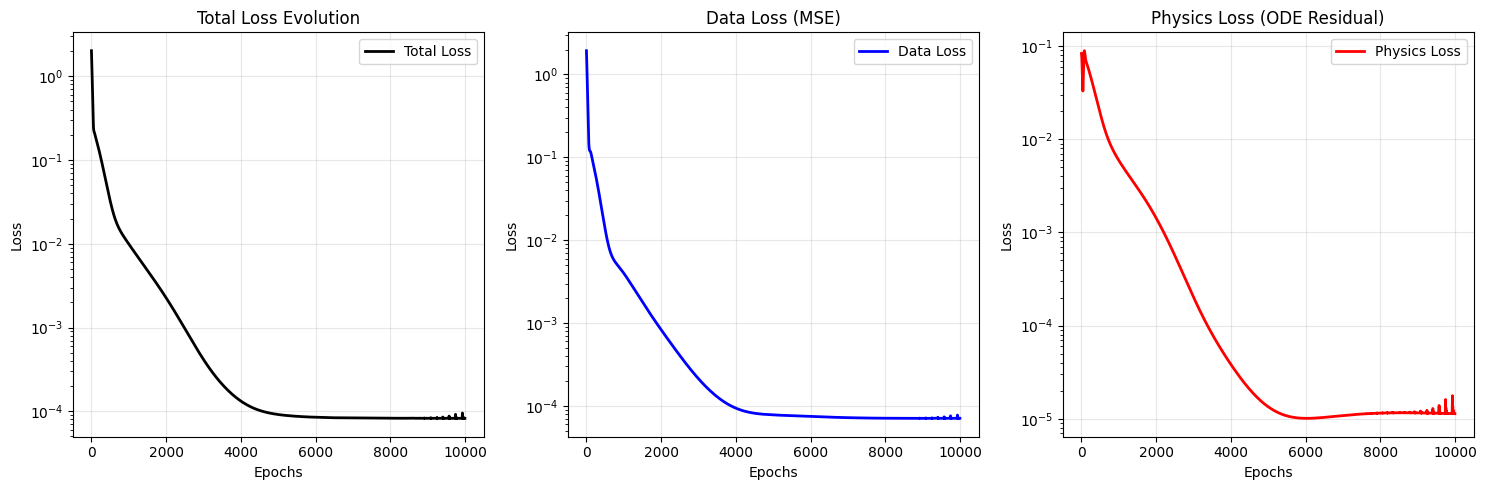

In [10]:
# Plot loss evolution
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

epochs_range = range(len(results['total_losses']))

# Total loss
ax1.plot(epochs_range, results['total_losses'], 'k-', linewidth=2, label='Total Loss')
ax1.set_title('Total Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Data loss
ax2.plot(epochs_range, results['data_losses'], 'b-', linewidth=2, label='Data Loss')
ax2.set_title('Data Loss (MSE)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Physics loss
ax3.plot(epochs_range, results['physics_losses'], 'r-', linewidth=2, label='Physics Loss')
ax3.set_title('Physics Loss (ODE Residual)')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Loss')
ax3.set_yscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

## Visualization: Parameter Evolution

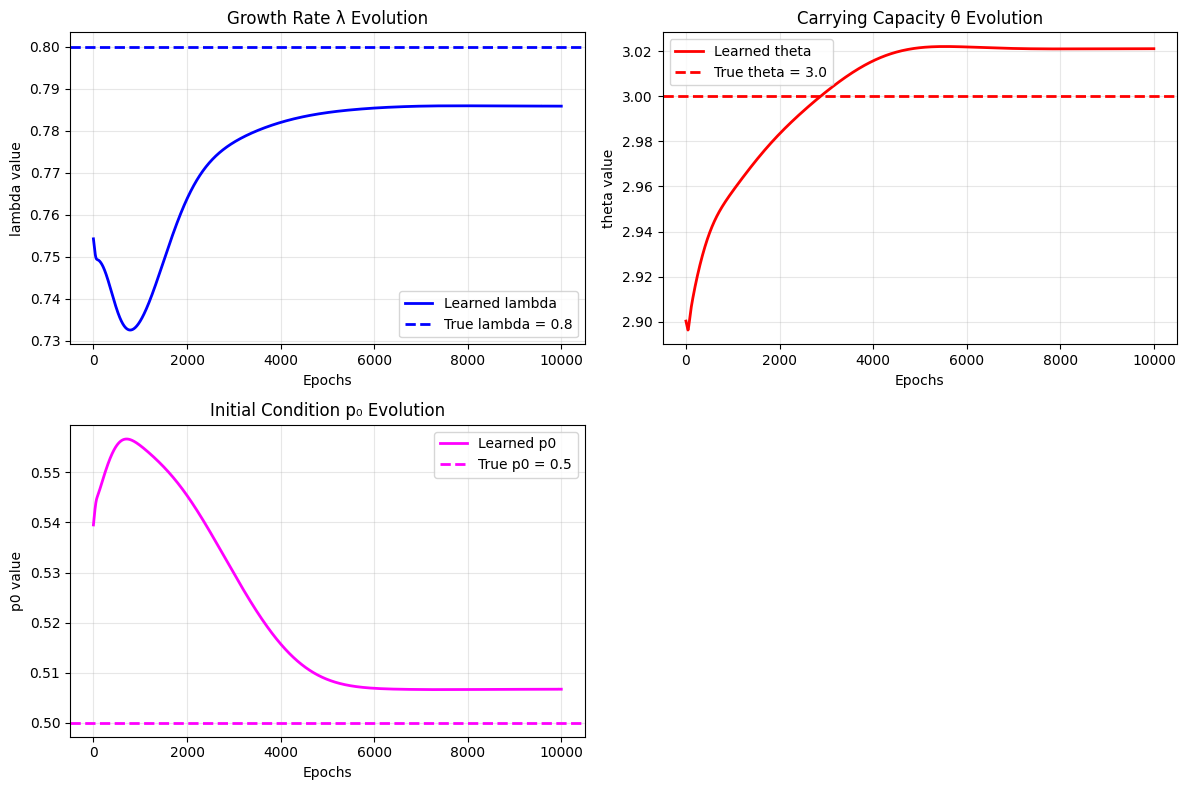

In [11]:
# Plot parameter evolution (only for trainable parameters)
trainable_params = [name for name, is_trainable in model.get_trainable_status().items() if is_trainable]
n_trainable = len(trainable_params)

if n_trainable > 0:
    # Create subplot grid based on number of trainable parameters
    cols = min(n_trainable, 2)
    rows = (n_trainable + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))

    # Ensure axes is always a flat list for consistent indexing
    if n_trainable == 1:
        axes = [axes]
    elif rows == 1 and cols > 1:
        axes = list(axes)
    elif rows > 1:
        axes = axes.flatten()
    else:
        axes = [axes]

    epochs_range = range(len(results['lambda_history']))

    param_data = {
        'lambda': (results['lambda_history'], lambda_true, 'Growth Rate λ', 'blue'),
        'theta': (results['theta_history'], theta_true, 'Carrying Capacity θ', 'red'),
        'alpha': (results['alpha_history'], alpha_true, 'Shape Parameter α', 'green'),
        'p0': (results['p0_history'], p0_true, 'Initial Condition p₀', 'magenta')
    }

    for i, param_name in enumerate(trainable_params):
        if i < len(axes):
            history, true_val, title, color = param_data[param_name]
            axes[i].plot(epochs_range, history, color=color, linewidth=2, label=f'Learned {param_name}')
            axes[i].axhline(y=true_val, color=color, linestyle='--', linewidth=2, label=f'True {param_name} = {true_val}')
            axes[i].set_title(f'{title} Evolution')
            axes[i].set_xlabel('Epochs')
            axes[i].set_ylabel(f'{param_name} value')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    # Hide extra subplots if any
    for i in range(n_trainable, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No trainable parameters to plot!")

## Visualization: Learned vs Ground Truth Solutions

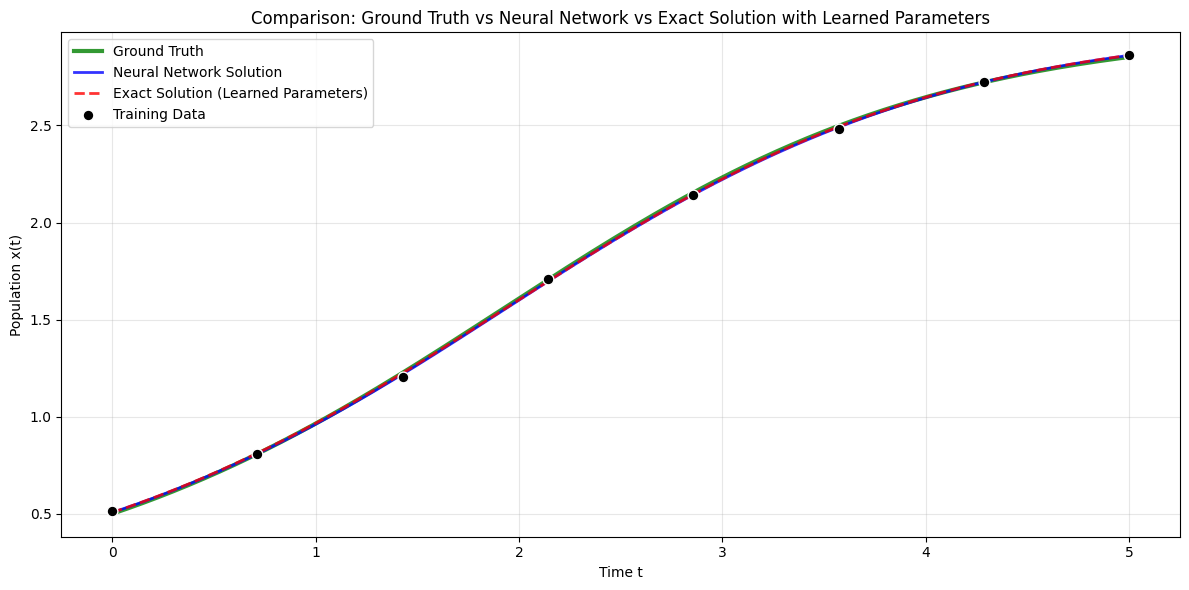


Solution Quality Comparison:
Neural Network - Mean error: 0.006316, Max error: 0.010687
Exact (learned params) - Mean error: 0.005136, Max error: 0.009206


In [12]:
# Compare learned solution with ground truth
t_test = torch.linspace(0, 5, 200).view(-1, 1)

model.eval()
with torch.no_grad():
    x_learned = model(t_test)
    x_true = ground_truth(t_test)

    # Compute exact solution using learned parameters
    params_final = model.get_parameters()
    def exact_solution_with_learned_params(t):
        return params_final['theta'] * (1.0 + (((params_final['theta'] / params_final['p0']) ** params_final['alpha']) - 1.0) * torch.exp(-params_final['alpha'] * params_final['lambda'] * t)) ** (-1.0 / params_final['alpha'])

    x_exact_learned = exact_solution_with_learned_params(t_test)

plt.figure(figsize=(12, 6))

plt.plot(t_test.numpy(), x_true.numpy(), 'g-', linewidth=3, label='Ground Truth', alpha=0.8)
plt.plot(t_test.numpy(), x_learned.numpy(), 'b-', linewidth=2, label='Neural Network Solution', alpha=0.8)
plt.plot(t_test.numpy(), x_exact_learned.numpy(), 'r--', linewidth=2, label='Exact Solution (Learned Parameters)', alpha=0.8)
plt.scatter(X.numpy(), Y.numpy(), color='black', s=60, label='Training Data', zorder=5, edgecolors='white')
plt.xlabel('Time t')
plt.ylabel('Population x(t)')
plt.title('Comparison: Ground Truth vs Neural Network vs Exact Solution with Learned Parameters')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print solution quality statistics
nn_error = torch.abs(x_learned - x_true).numpy()
exact_error = torch.abs(x_exact_learned - x_true).numpy()
print(f"\nSolution Quality Comparison:")
print(f"Neural Network - Mean error: {nn_error.mean():.6f}, Max error: {nn_error.max():.6f}")
print(f"Exact (learned params) - Mean error: {exact_error.mean():.6f}, Max error: {exact_error.max():.6f}")

## Summary

In [13]:
# Create a comprehensive parameter comparison table
import pandas as pd

# Only include trainable parameters in the comparison
trainable_status = model.get_trainable_status()
trainable_params = [name for name, is_trainable in trainable_status.items() if is_trainable]

if trainable_params:
    param_names = {
        'lambda': 'λ (Growth Rate)',
        'theta': 'θ (Carrying Capacity)',
        'alpha': 'α (Shape Parameter)',
        'p0': 'p₀ (Initial Condition)'
    }

    true_values = {
        'lambda': lambda_true,
        'theta': theta_true,
        'alpha': alpha_true,
        'p0': p0_true
    }

    comparison_data = {
        'Parameter': [param_names[p] for p in trainable_params],
        'True Value': [true_values[p] for p in trainable_params],
        'Learned Value': [params_final[p] for p in trainable_params],
        'Absolute Error': [abs(params_final[p] - true_values[p]) for p in trainable_params],
        'Relative Error (%)': [100 * abs(params_final[p] - true_values[p]) / true_values[p] for p in trainable_params]
    }

    df = pd.DataFrame(comparison_data)
    print("\n" + "="*80)
    print("PARAMETER DISCOVERY RESULTS (Trainable Parameters Only)")
    print("="*80)
    print(df.to_string(index=False, float_format='%.4f'))
    print("="*80)

else:
    print("No trainable parameters to analyze!")


PARAMETER DISCOVERY RESULTS (Trainable Parameters Only)
             Parameter  True Value  Learned Value  Absolute Error  Relative Error (%)
       λ (Growth Rate)      0.8000         0.7858          0.0142              1.7746
 θ (Carrying Capacity)      3.0000         3.0211          0.0211              0.7019
p₀ (Initial Condition)      0.5000         0.5067          0.0067              1.3337
